# 在自定义数据集上微调语义分割模型并通过推理 API 使用


_作者：[Sergio Paniego](https://github.com/sergiopaniego)_

在本 Notebook 中，我们将介绍如何在自定义数据集上微调一个 [语义分割](https://huggingface.co/tasks/image-segmentation) 模型。我们将使用的模型是预训练的 [Segformer](https://huggingface.co/docs/transformers/model_doc/segformer)，这是一个强大且灵活的基于 Transformer 的分割架构，适用于各种分割任务。

![Segformer 架构](https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/segformer_architecture.png)

对于我们的数据集，我们将使用 [segments/sidewalk-semantic](https://huggingface.co/datasets/segments/sidewalk-semantic)，它包含了标注好的人行道图像，十分适合用于城市环境中的应用。

### 示例应用场景： 
该模型可以部署在送餐机器人中，使其能够自动在城市人行道上导航，将披萨直接送到您家门口 🍕。

一旦我们微调完成该模型，接下来会演示如何使用 [Serverless 推理 API](https://huggingface.co/docs/api-inference/index) 将模型部署，使其可以通过一个简单的 API 端点进行访问。

## 1. 安装依赖
首先，我们需要安装微调语义分割模型所需的必要库。以下是安装依赖的步骤：


In [ ]:
!pip install -q datasets transformers evaluate wandb
# Tested with datasets==3.0.0, transformers==4.44.2, evaluate==0.4.3, wandb==0.18.1

## 2. 加载数据集 📁

我们将使用 [sidewalk-semantic](https://huggingface.co/datasets/segments/sidewalk-semantic) 数据集，该数据集包含了 2021 年夏季在比利时收集的关于人行道的图像。

该数据集包括：

* **1,000 张图像及其对应的语义分割掩膜** 🖼
* **34 个不同的类别** 📦

由于该数据集是受限访问的，你需要登录并接受许可才能访问。同时，我们还需要身份验证来上传微调后的模型到 Hugging Face Hub。

In [ ]:
from huggingface_hub import notebook_login

notebook_login()

In [3]:
sidewalk_dataset_identifier = "segments/sidewalk-semantic"

In [ ]:
from datasets import load_dataset

dataset = load_dataset(sidewalk_dataset_identifier)

审查数据集的内部结构以熟悉它！

In [5]:
dataset

DatasetDict({
    train: Dataset({
        features: ['pixel_values', 'label'],
        num_rows: 1000
    })
})

由于数据集仅包含训练集，我们将手动将其分为 `训练集` 和 `测试集`。我们将 80% 的数据分配用于训练，剩余的 20% 用于评估和测试。 ➗

In [6]:
dataset = dataset.shuffle(seed=42)
dataset = dataset["train"].train_test_split(test_size=0.2)
train_ds = dataset["train"]
test_ds = dataset["test"]

让我们检查一个示例中存在的对象类型。我们可以看到，`pixels_values` 包含了 RGB 图像，而 `label` 包含了 ground truth mask。ground truth mask 是一个单通道图像，其中每个像素表示对应 RGB 图像中像素的类别。

In [7]:
image = train_ds[0]
image

{'pixel_values': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=1920x1080>,
 'label': <PIL.PngImagePlugin.PngImageFile image mode=L size=1920x1080>}

## 3. 可视化示例！ 👀

现在我们已经加载了数据集，让我们可视化一些示例以及它们的掩膜，以便更好地理解数据集的结构。

数据集包含一个 JSON [文件](https://huggingface.co/datasets/segments/sidewalk-semantic/blob/main/id2label.json)，该文件包含了 `id2label` 映射。我们将打开这个文件，读取与每个 ID 关联的类别标签。

In [8]:
import json
from huggingface_hub import hf_hub_download

filename = "id2label.json"
id2label = json.load(open(hf_hub_download(repo_id=sidewalk_dataset_identifier, filename=filename, repo_type="dataset"), "r"))
id2label = {int(k): v for k, v in id2label.items()}
label2id = {v: k for k, v in id2label.items()}

num_labels = len(id2label)
print("Id2label:", id2label)

id2label.json:   0%|          | 0.00/852 [00:00<?, ?B/s]

Id2label: {0: 'unlabeled', 1: 'flat-road', 2: 'flat-sidewalk', 3: 'flat-crosswalk', 4: 'flat-cyclinglane', 5: 'flat-parkingdriveway', 6: 'flat-railtrack', 7: 'flat-curb', 8: 'human-person', 9: 'human-rider', 10: 'vehicle-car', 11: 'vehicle-truck', 12: 'vehicle-bus', 13: 'vehicle-tramtrain', 14: 'vehicle-motorcycle', 15: 'vehicle-bicycle', 16: 'vehicle-caravan', 17: 'vehicle-cartrailer', 18: 'construction-building', 19: 'construction-door', 20: 'construction-wall', 21: 'construction-fenceguardrail', 22: 'construction-bridge', 23: 'construction-tunnel', 24: 'construction-stairs', 25: 'object-pole', 26: 'object-trafficsign', 27: 'object-trafficlight', 28: 'nature-vegetation', 29: 'nature-terrain', 30: 'sky', 31: 'void-ground', 32: 'void-dynamic', 33: 'void-static', 34: 'void-unclear'}


让我们为每个类别分配颜色 🎨。这将帮助我们更有效地可视化分割结果，并使得在图像中解释不同类别变得更加容易。

In [9]:
sidewalk_palette = [
  [0, 0, 0], # unlabeled
  [216, 82, 24], # flat-road
  [255, 255, 0], # flat-sidewalk
  [125, 46, 141], # flat-crosswalk
  [118, 171, 47], # flat-cyclinglane
  [161, 19, 46], # flat-parkingdriveway
  [255, 0, 0], # flat-railtrack
  [0, 128, 128], # flat-curb
  [190, 190, 0], # human-person
  [0, 255, 0], # human-rider
  [0, 0, 255], # vehicle-car
  [170, 0, 255], # vehicle-truck
  [84, 84, 0], # vehicle-bus
  [84, 170, 0], # vehicle-tramtrain
  [84, 255, 0], # vehicle-motorcycle
  [170, 84, 0], # vehicle-bicycle
  [170, 170, 0], # vehicle-caravan
  [170, 255, 0], # vehicle-cartrailer
  [255, 84, 0], # construction-building
  [255, 170, 0], # construction-door
  [255, 255, 0], # construction-wall
  [33, 138, 200], # construction-fenceguardrail
  [0, 170, 127], # construction-bridge
  [0, 255, 127], # construction-tunnel
  [84, 0, 127], # construction-stairs
  [84, 84, 127], # object-pole
  [84, 170, 127], # object-trafficsign
  [84, 255, 127], # object-trafficlight
  [170, 0, 127], # nature-vegetation
  [170, 84, 127], # nature-terrain
  [170, 170, 127], # sky
  [170, 255, 127], # void-ground
  [255, 0, 127], # void-dynamic
  [255, 84, 127], # void-static
  [255, 170, 127], # void-unclear
]

我们可以可视化数据集中的一些示例，包括 RGB 图像、对应的掩膜以及掩膜覆盖在图像上的效果。这将帮助我们更好地理解数据集以及掩膜如何与图像对应。📸

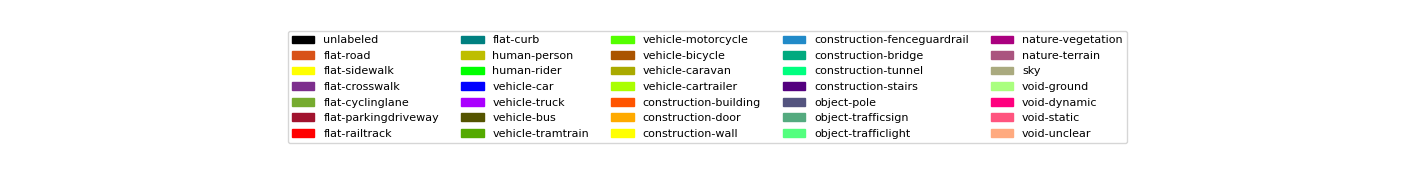

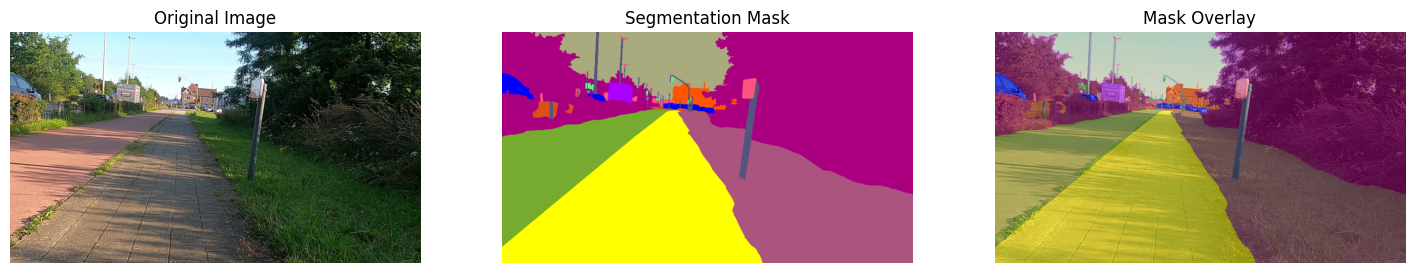

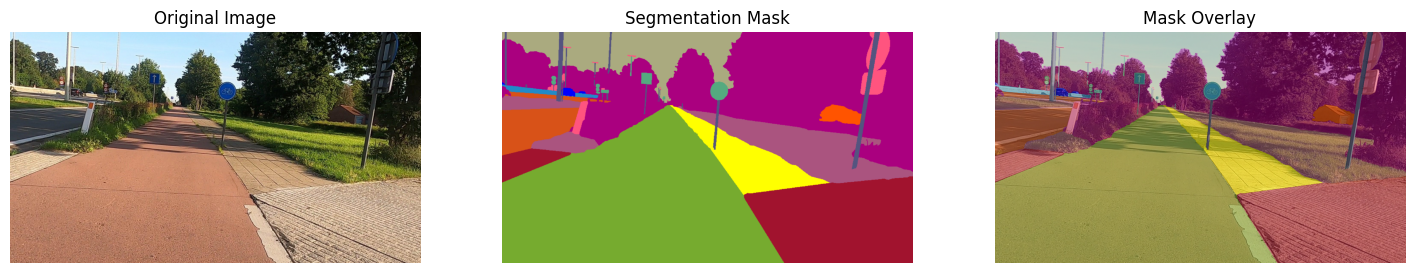

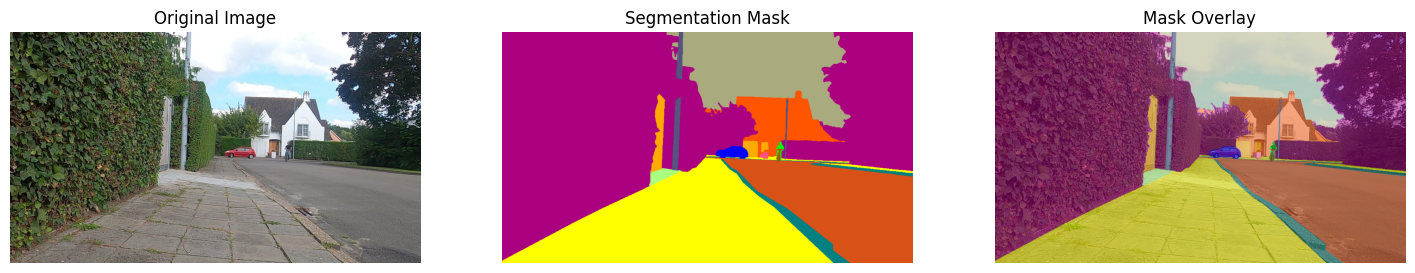

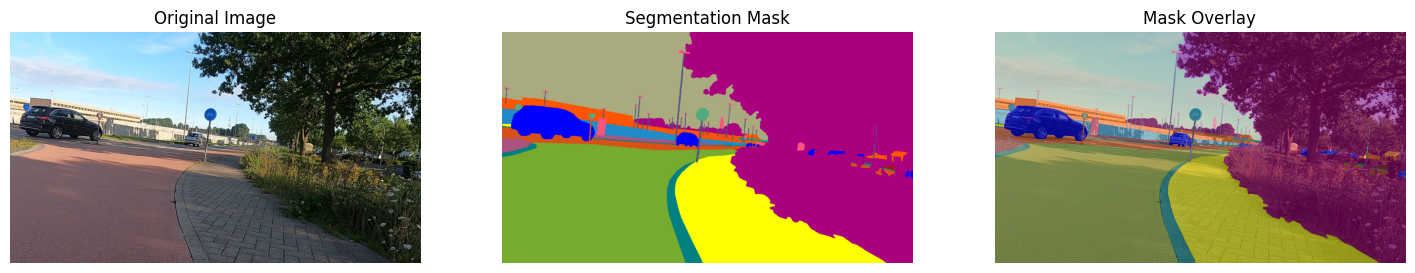

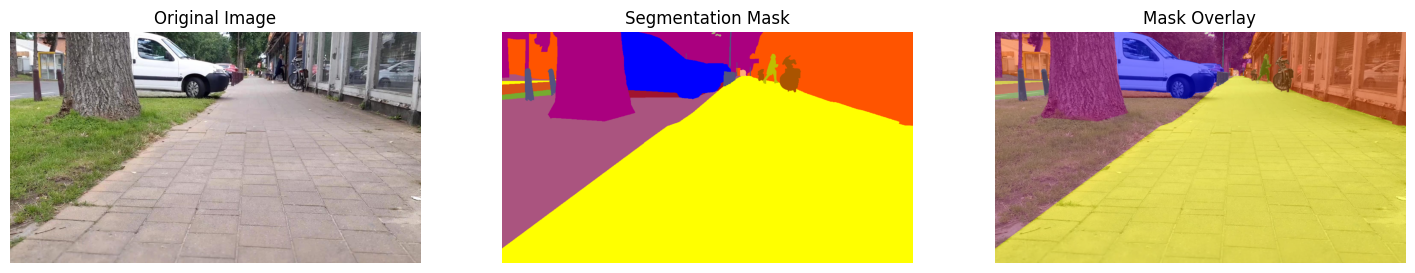

In [10]:
from matplotlib import pyplot as plt
import numpy as np
from PIL import Image
import matplotlib.patches as patches

# Create and show the legend separately
fig, ax = plt.subplots(figsize=(18, 2))

legend_patches = [patches.Patch(color=np.array(color)/255, label=label) for label, color in zip(id2label.values(), sidewalk_palette)]

ax.legend(handles=legend_patches, loc='center', bbox_to_anchor=(0.5, 0.5), ncol=5, fontsize=8)
ax.axis('off')

plt.show()

for i in range(5):
    image = train_ds[i]

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))

    # Show the original image
    ax[0].imshow(image['pixel_values'])
    ax[0].set_title('Original Image')
    ax[0].axis('off')

    mask_np = np.array(image['label'])

    # Create a new empty RGB image
    colored_mask = np.zeros((mask_np.shape[0], mask_np.shape[1], 3), dtype=np.uint8)

    # Assign colors to each value in the mask
    for label_id, color in enumerate(sidewalk_palette):
        colored_mask[mask_np == label_id] = color

    colored_mask_img = Image.fromarray(colored_mask, 'RGB')

    # Show the segmentation mask
    ax[1].imshow(colored_mask_img)
    ax[1].set_title('Segmentation Mask')
    ax[1].axis('off')

    # Convert the original image to RGBA to support transparency
    image_rgba = image['pixel_values'].convert("RGBA")
    colored_mask_rgba = colored_mask_img.convert("RGBA")

    # Adjust transparency of the mask
    alpha = 128  # Transparency level (0 fully transparent, 255 fully opaque)
    image_2_with_alpha = Image.new("RGBA", colored_mask_rgba.size)
    for x in range(colored_mask_rgba.width):
        for y in range(colored_mask_rgba.height):
            r, g, b, a = colored_mask_rgba.getpixel((x, y))
            image_2_with_alpha.putpixel((x, y), (r, g, b, alpha))

    superposed = Image.alpha_composite(image_rgba, image_2_with_alpha)

    # Show the mask overlay
    ax[2].imshow(superposed)
    ax[2].set_title('Mask Overlay')
    ax[2].axis('off')

    plt.show()

## 4. 可视化类别分布 📊

为了更深入地了解数据集，让我们绘制每个类别的出现次数。这将帮助我们理解各类别的分布情况，并识别数据集中的潜在偏差或不平衡问题。

In [11]:
import matplotlib.pyplot as plt
import numpy as np

class_counts = np.zeros(len(id2label))

for example in train_ds:
    mask_np = np.array(example['label'])
    unique, counts = np.unique(mask_np, return_counts=True)
    for u, c in zip(unique, counts):
        class_counts[u] += c

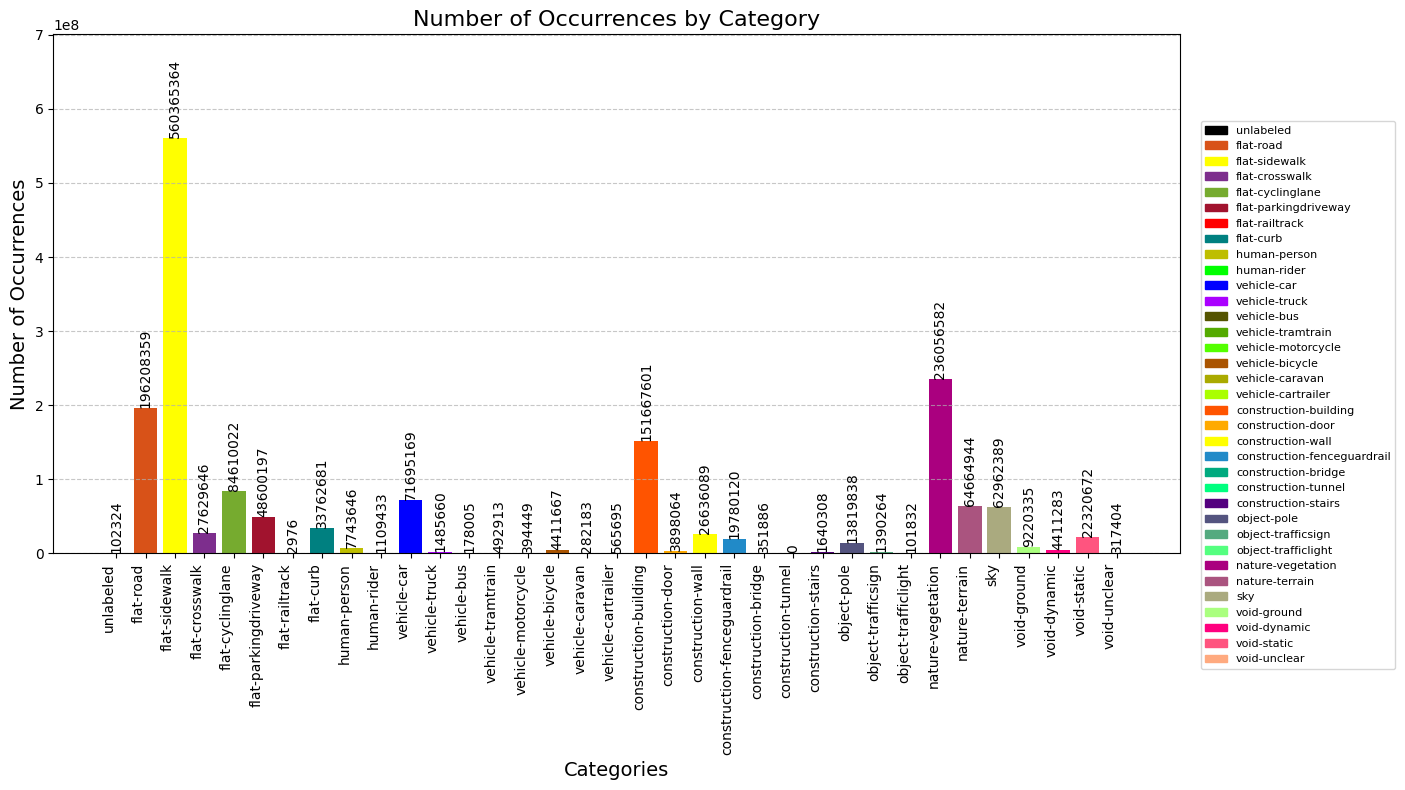

In [12]:
from matplotlib import pyplot as plt
import numpy as np
from matplotlib import patches

labels = list(id2label.values())

# Normalize colors to be in the range [0, 1]
normalized_palette = [tuple(c / 255 for c in color) for color in sidewalk_palette]

# Visualization
fig, ax = plt.subplots(figsize=(12, 8))

bars = ax.bar(range(len(labels)), class_counts, color=[normalized_palette[i] for i in range(len(labels))])

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=90, ha="right")

ax.set_xlabel("Categories", fontsize=14)
ax.set_ylabel("Number of Occurrences", fontsize=14)
ax.set_title("Number of Occurrences by Category", fontsize=16)

ax.grid(axis="y", linestyle="--", alpha=0.7)

# Adjust the y-axis limit
y_max = max(class_counts)
ax.set_ylim(0, y_max * 1.25)

for bar in bars:
    height = int(bar.get_height())
    offset = 10  # Adjust the text location
    ax.text(bar.get_x() + bar.get_width() / 2.0, height + offset, f"{height}",
            ha="center", va="bottom", rotation=90, fontsize=10, color='black')

fig.legend(handles=legend_patches, loc='center left', bbox_to_anchor=(1, 0.5), ncol=1, fontsize=8)  # Adjust ncol as needed

plt.tight_layout()
plt.show()


## 5. 初始化图像处理器并使用 Albumentations 添加数据增强 📸

我们将首先初始化图像处理器，然后使用 [Albumentations](https://albumentations.ai/) 应用数据增强 🪄。这将有助于增强我们的数据集，并提高语义分割模型的性能。

In [13]:
import albumentations as A
from transformers import SegformerImageProcessor

image_processor = SegformerImageProcessor()

albumentations_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=30, p=0.7),
    A.RandomResizedCrop(height=512, width=512, scale=(0.8, 1.0), ratio=(0.75, 1.33), p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.25, contrast_limit=0.25, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=25, val_shift_limit=20, p=0.5),
    A.GaussianBlur(blur_limit=(3, 5), p=0.3),
    A.GaussNoise(var_limit=(10, 50), p=0.4),
])

def train_transforms(example_batch):
    augmented_images = [albumentations_transform(image=np.array(x))['image'] for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['label']]
    inputs = image_processor(augmented_images, labels)
    return inputs

def val_transforms(example_batch):
    images = [x for x in example_batch['pixel_values']]
    labels = [x for x in example_batch['label']]
    inputs = image_processor(images, labels)
    return inputs


# Set transforms
train_ds.set_transform(train_transforms)
test_ds.set_transform(val_transforms)

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

## 6. 从检查点初始化模型

我们将使用来自检查点的预训练 Segformer 模型：[nvidia/mit-b0](https://huggingface.co/nvidia/mit-b0)。该架构在论文 [SegFormer: Simple and Efficient Design for Semantic Segmentation with Transformers](https://arxiv.org/abs/2105.15203) 中有详细描述，并且已在 ImageNet-1k 数据集上进行训练。

In [ ]:
from transformers import SegformerForSemanticSegmentation

pretrained_model_name = "nvidia/mit-b0"
model = SegformerForSemanticSegmentation.from_pretrained(
    pretrained_model_name,
    id2label=id2label,
    label2id=label2id
)

## 7. 设置训练参数并连接到 Weights & Biases (W&B) 📉

接下来，我们将配置训练参数，并连接到 [Weights & Biases (W&B)](https://wandb.ai/)。W&B 将帮助我们跟踪实验、可视化指标，并管理模型训练工作流，在整个过程中提供有价值的洞察。

In [ ]:
from transformers import TrainingArguments

output_dir = "segformer-b0-segments-sidewalk-finetuned"

training_args = TrainingArguments(
    output_dir=output_dir,
    learning_rate=6e-5,
    num_train_epochs=20,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    save_total_limit=2,
    evaluation_strategy="steps",
    save_strategy="steps",
    save_steps=20,
    eval_steps=20,
    logging_steps=1,
    eval_accumulation_steps=5,
    load_best_model_at_end=True,
    push_to_hub=True,
    report_to="wandb"
)

In [ ]:
import wandb

wandb.init(
    project="segformer-b0-segments-sidewalk-finetuned",  # change this
    name="segformer-b0-segments-sidewalk-finetuned",  # change this
    config=training_args,
)

## 8. 设置自定义 `compute_metrics` 方法以增强使用 `evaluate` 的日志记录

我们将使用 [平均交并比 (mean IoU)](https://huggingface.co/spaces/evaluate-metric/mean_iou) 作为评估模型性能的主要指标。这将使我们能够详细跟踪每个类别的性能。

此外，我们将调整评估模块的日志记录级别，以减少输出中的警告。如果图像中没有检测到某个类别，你可能会看到类似以下的警告：

```
RuntimeWarning: invalid value encountered in divide iou = total_area_intersect / total_area_union
```

如果你希望跳过这些警告并继续执行后续步骤，可以跳过此单元。

In [17]:
import evaluate
evaluate.logging.set_verbosity_error()

In [ ]:
import torch
from torch import nn
import multiprocessing

metric = evaluate.load("mean_iou")

def compute_metrics(eval_pred):
  with torch.no_grad():
    logits, labels = eval_pred
    logits_tensor = torch.from_numpy(logits)
    # scale the logits to the size of the label
    logits_tensor = nn.functional.interpolate(
        logits_tensor,
        size=labels.shape[-2:],
        mode="bilinear",
        align_corners=False,
    ).argmax(dim=1)

    # currently using _compute instead of compute: https://github.com/huggingface/evaluate/pull/328#issuecomment-1286866576
    pred_labels = logits_tensor.detach().cpu().numpy()
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        metrics = metric._compute(
                predictions=pred_labels,
                references=labels,
                num_labels=len(id2label),
                ignore_index=0,
                reduce_labels=image_processor.do_reduce_labels,
            )

    # add per category metrics as individual key-value pairs
    per_category_accuracy = metrics.pop("per_category_accuracy").tolist()
    per_category_iou = metrics.pop("per_category_iou").tolist()

    metrics.update({f"accuracy_{id2label[i]}": v for i, v in enumerate(per_category_accuracy)})
    metrics.update({f"iou_{id2label[i]}": v for i, v in enumerate(per_category_iou)})

    return metrics

## 9. 在我们的数据集上训练模型 🏋

现在是时候在我们的自定义数据集上训练模型了。我们将使用已经准备好的训练参数，并通过连接的 Weights & Biases 集成来监控训练过程，并根据需要进行调整。让我们开始训练，并观察模型如何提高其性能！

In [19]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    tokenizer=image_processor,
    compute_metrics=compute_metrics,
)

In [ ]:
trainer.train()

## 10. 在新图像上评估模型性能 📸

训练完成后，我们将评估模型在新图像上的表现。我们将使用一张测试图像，并利用 [pipeline](https://huggingface.co/docs/transformers/main_classes/pipelines) 来评估模型在未见过的数据上的表现。

In [ ]:
import requests
from transformers import pipeline
import numpy as np
from PIL import Image, ImageDraw

url = "https://images.unsplash.com/photo-1594098742644-314fedf61fb6?q=80&w=2672&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"

image = Image.open(requests.get(url, stream=True).raw)

image_segmentator = pipeline(
    "image-segmentation", model="sergiopaniego/segformer-b0-segments-sidewalk-finetuned" # Change with your model name
)

results = image_segmentator(image)

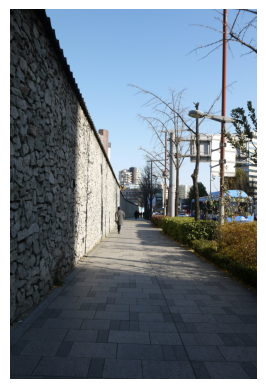

In [42]:
plt.imshow(image)
plt.axis('off')
plt.show()

模型已经生成了一些掩码，我们可以可视化这些掩码以评估和理解其性能。这将帮助我们查看模型在图像分割上的表现如何，并识别需要改进的地方。

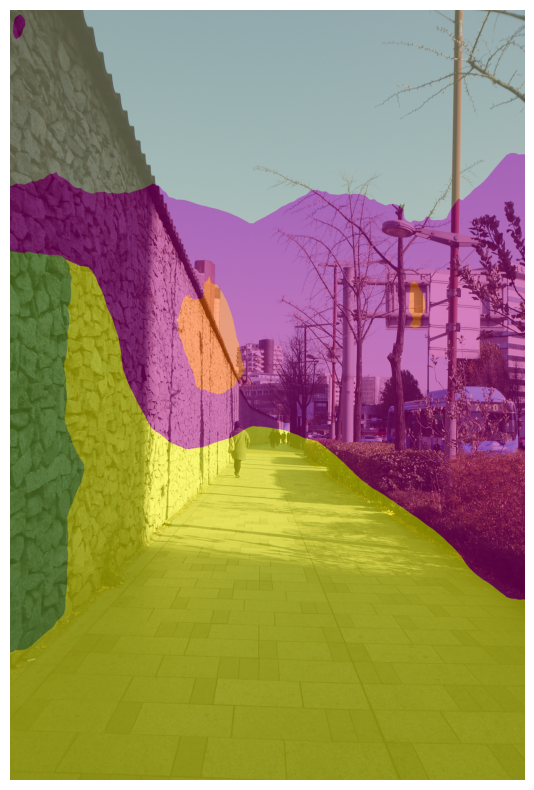

In [43]:
image_array = np.array(image)

segmentation_map = np.zeros_like(image_array)

for result in results:
    mask = np.array(result['mask'])
    label = result['label']

    label_index = list(id2label.values()).index(label)

    color = sidewalk_palette[label_index]

    for c in range(3):
        segmentation_map[:, :, c] = np.where(mask, color[c], segmentation_map[:, :, c])

plt.figure(figsize=(10, 10))
plt.imshow(image_array)
plt.imshow(segmentation_map, alpha=0.5)
plt.axis('off')
plt.show()

## 11. 在测试集上评估性能 📊


In [ ]:
metrics = trainer.evaluate(test_ds)
print(metrics)

## 12. 使用推理 API 访问模型并可视化结果 🔌


Hugging Face 🤗 提供了一个 [无服务器推理 API](https://huggingface.co/docs/api-inference/index)，允许你通过 API 端点直接测试模型，且可以免费使用。有关如何使用该 API 的详细指导，请参阅这个 [指南](https://huggingface.co/learn/cookbook/enterprise_hub_serverless_inference_api)。

我们将利用这个 API 来探索其功能，并看看它如何帮助我们测试模型。

**重要提示**

在使用无服务器推理 API 之前，你需要通过创建模型卡来设置模型任务。在为你的微调模型创建模型卡时，确保正确指定任务。

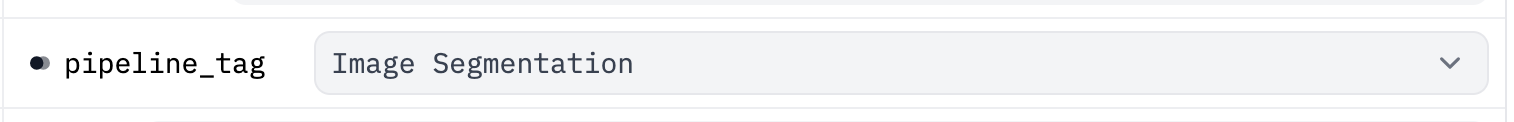


一旦模型任务设置完成，我们可以下载一张图片并使用 [InferenceClient](https://huggingface.co/docs/huggingface_hub/v0.25.0/en/package_reference/inference_client) 来测试模型。这个客户端将允许我们通过 API 将图片发送到模型，并获取结果以进行评估。

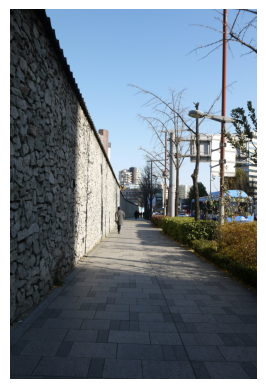

In [24]:
url = "https://images.unsplash.com/photo-1594098742644-314fedf61fb6?q=80&w=2672&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D"
image = Image.open(requests.get(url, stream=True).raw)

plt.imshow(image)
plt.axis('off')
plt.show()

我们将使用 InferenceClient 的 [image_segmentation](https://huggingface.co/docs/huggingface_hub/v0.25.0/en/package_reference/inference_client#huggingface_hub.InferenceClient.image_segmentation) 方法。该方法接受模型和图片作为输入，并返回预测的掩码。这将帮助我们测试模型在新图片上的表现。

In [ ]:
from huggingface_hub import InferenceClient

client = InferenceClient()

response = client.image_segmentation(
    model="sergiopaniego/segformer-b0-segments-sidewalk-finetuned", # Change with your model name
    image='https://images.unsplash.com/photo-1594098742644-314fedf61fb6?q=80&w=2672&auto=format&fit=crop&ixlib=rb-4.0.3&ixid=M3wxMjA3fDB8MHxwaG90by1wYWdlfHx8fGVufDB8fHx8fA%3D%3D'
)

print(response)

通过预测的掩码，我们可以展示结果。

/usr/local/lib/python3.10/dist-packages/huggingface_hub/inference/_generated/types/base.py:139: FutureWarning: Accessing 'ImageSegmentationOutputElement' values through dict is deprecated and will be removed from version '0.25'. Use dataclass attributes instead.
  warnings.warn(


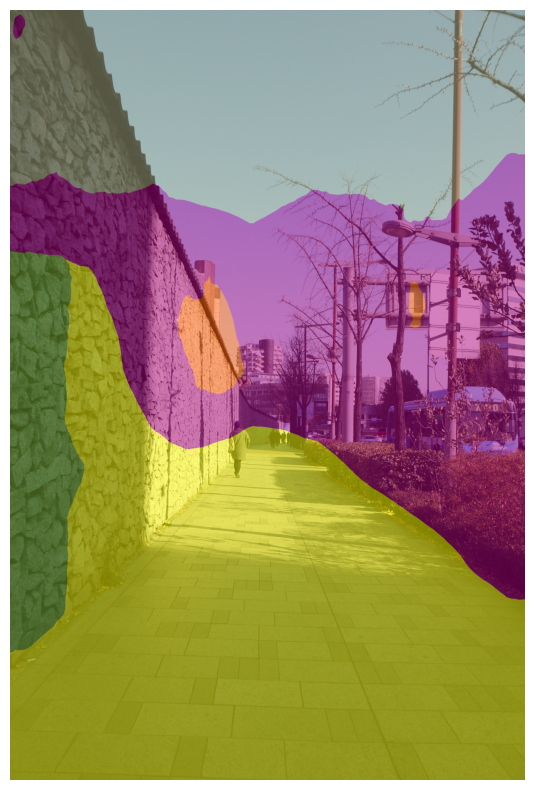

In [26]:
image_array = np.array(image)
segmentation_map = np.zeros_like(image_array)

for result in response:
    mask = np.array(result['mask'])
    label = result['label']

    label_index = list(id2label.values()).index(label)

    color = sidewalk_palette[label_index]

    for c in range(3):
        segmentation_map[:, :, c] = np.where(mask, color[c], segmentation_map[:, :, c])

plt.figure(figsize=(10, 10))
plt.imshow(image_array)
plt.imshow(segmentation_map, alpha=0.5)
plt.axis('off')
plt.show()

也可以使用 [JavaScript 版 Inference API](https://huggingface.co/tasks/image-segmentation)。下面是如何使用 JavaScript 调用该 API 的示例：

```javascript
import { HfInference } from "@huggingface/inference";

const inference = new HfInference(HF_TOKEN);
await inference.imageSegmentation({
    data: await (await fetch("https://picsum.photos/300/300")).blob(),
    model: "sergiopaniego/segformer-b0-segments-sidewalk-finetuned",
});
```

这个示例展示了如何用 JavaScript 获取图片并将其传递给指定的模型进行图像分割任务。

**额外加分**

你还可以通过 Hugging Face Space 部署微调后的模型。例如，我创建了一个自定义 Space 来展示这个过程：[Semantic Segmentation with SegFormer Fine-Tuned on Segments/Sidewalk](https://huggingface.co/spaces/sergiopaniego/segformer-b0-segments-sidewalk-finetuned)。

<img src="https://huggingface.co/front/thumbnails/spaces.png" alt="HF Spaces logo" width="20%">

In [44]:
from IPython.display import IFrame
IFrame(src='https://sergiopaniego-segformer-b0-segments-sidewalk-finetuned.hf.space', width=1000, height=800)

## 总结

在本指南中，我们成功地在自定义数据集上微调了一个语义分割模型，并利用无服务器推理 API 进行了测试。这展示了如何轻松地将模型集成到各种应用中，并利用 Hugging Face 工具进行部署。

希望本指南能够为你提供所需的工具和知识，使你能够自信地微调和部署自己的模型！🚀